Plotting with transform_first=True took: 0.040 seconds


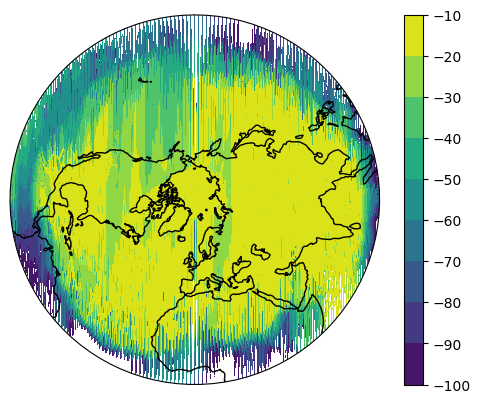

In [ ]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import time

fil = "/Users/brianpm/Documents/cesm2_lens_data/SWCF/b.e21.BHISTsmbb.f09_g17.LE2-1151.008.cam.h0.SWCF.188001-188912.nc"

ds = xr.open_dataset(fil).isel(time=100)

x = ds['SWCF']

x_nh = x.sel(lat=slice(0,90))
x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x.lon)
lons, lats = np.meshgrid(lon_cyclic, x_nh.lat)
levels = np.arange(-100, 0, 10)

proj = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(subplot_kw={"projection":proj})

start_time = time.time()
img1 = ax.contourf(lons, lats, x_cyclic, levels=levels, transform=ccrs.PlateCarree(), transform_first=True) # <--- ADD THIS
ax.coastlines()blob:vscode-webview://1ks14qpj37b2dr9nrslohbta38irmj3l0c7i2h9rgh7p09fnhrkb/c0567e0e-33e1-43ee-acd4-61a034630fe8
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

end_time = time.time()
print(f"Plotting with transform_first=True took: {end_time - start_time:.3f} seconds")
plt.show()

Plotting with pcolormesh + contour lines took: 0.175 seconds


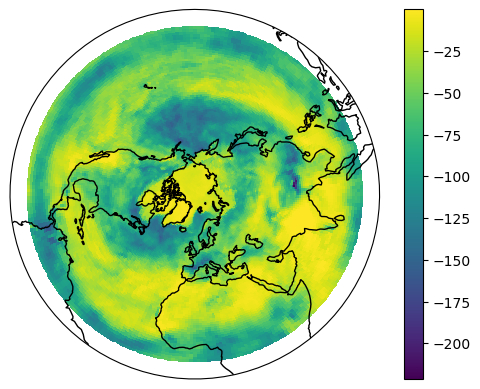

CPU times: user 245 ms, sys: 4.44 ms, total: 250 ms
Wall time: 249 ms


In [4]:
%%time
# ... (initial data loading and processing) ...

proj = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(subplot_kw={"projection":proj})

start_time = time.time()

# Use pcolormesh for the filled regions
img1 = ax.pcolormesh(lons, lats, x_cyclic, transform=ccrs.PlateCarree(), cmap='viridis') # Choose a colormap

# Overlay contour lines for the "contour" look
# ax.contour(lons, lats, x_cyclic, levels=levels, colors='k', linewidths=0.5, transform=ccrs.PlateCarree()) # Black lines, thin

ax.coastlines()
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

end_time = time.time()
print(f"Plotting with pcolormesh + contour lines took: {end_time - start_time:.3f} seconds")
plt.show()

[[ 1.55256763e-07 -2.75089288e+05 -5.50047648e+05 ...  5.50047648e+05
   2.75089288e+05 -1.55256763e-07]
 [ 1.52740414e-07 -2.70630733e+05 -5.41132660e+05 ...  5.41132660e+05
   2.70630733e+05 -1.52740414e-07]
 [ 1.50263838e-07 -2.66242651e+05 -5.32358584e+05 ...  5.32358584e+05
   2.66242651e+05 -1.50263838e-07]
 ...
 [ 2.59218659e-09 -4.59292560e+03 -9.18366522e+03 ...  9.18366522e+03
   4.59292560e+03 -2.59218659e-09]
 [ 1.29600917e-09 -2.29631375e+03 -4.59153458e+03 ...  4.59153458e+03
   2.29631375e+03 -1.29600917e-09]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[12610164.45554021 12607163.5778819  12598162.37316221 ...
  12598162.37316221 12607163.5778819  12610164.45554021]
 [12405783.13645399 12402830.896015   12393975.57980457 ...
  12393975.57980457 12402830.896015   12405783.13645399]
 [12204632.30853442 12201727.93654532 12193016.2029018  ...
  12193016.2029018  12201727.93654532 12204632.30853442]
 ...
 [  2105

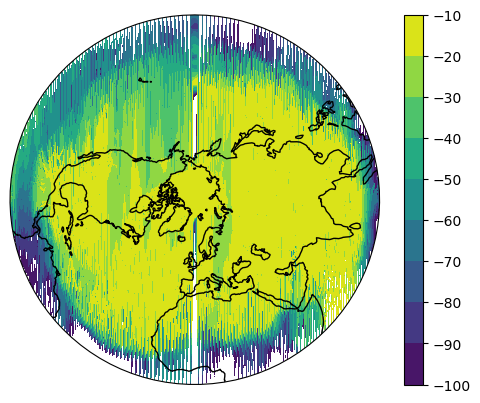

In [18]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import time

fil = "/Users/brianpm/Documents/cesm2_lens_data/SWCF/b.e21.BHISTsmbb.f09_g17.LE2-1151.008.cam.h0.SWCF.188001-188912.nc"

ds = xr.open_dataset(fil).isel(time=100)

x = ds['SWCF']

x_nh = x.sel(lat=slice(0,90))

# --- IMPORTANT: Convert longitudes to -180 to 180 range ---
# This is typically done on the lon coordinate directly.
# Let's create a new DataArray with adjusted longitudes
lon_180 = (x_nh.lon + 180) % 360 - 180
x_nh_adjusted = x_nh.assign_coords(lon=lon_180).sortby('lon')


# Add cyclic point after converting to -180 to 180
# The add_cyclic_point function handles the coordinate correctly
x_cyclic, lon_cyclic = add_cyclic_point(x_nh_adjusted, coord=x_nh_adjusted.lon)

lons, lats = np.meshgrid(lon_cyclic, x_nh_adjusted.lat) # Use adjusted lats too for consistency


levels = np.arange(-100, 0, 10)

proj = ccrs.NorthPolarStereo(central_longitude=0)
fig, ax = plt.subplots(subplot_kw={"projection":proj})


# Get the transformed coordinates (for debugging)
x_proj, y_proj = proj.transform_points(ccrs.PlateCarree(), lons, lats)[:, :, 0], \
                 proj.transform_points(ccrs.PlateCarree(), lons, lats)[:, :, 1]
print(x_proj)
print(y_proj)


start_time = time.time()
img1 = ax.contourf(lons, lats, x_cyclic, levels=levels, transform=ccrs.PlateCarree(), transform_first=True)
ax.coastlines()
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

end_time = time.time()
print(f"Plotting with transform_first=True and -180/180 longitudes took: {end_time - start_time:.3f} seconds")
plt.show()

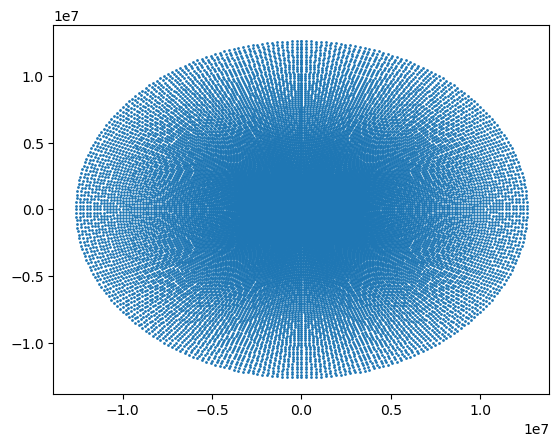

In [15]:
plt.plot(x_proj.flatten(), y_proj.flatten(), 'o', markersize=1)

In [16]:
x_proj.min()

np.float64(-12610164.455540212)

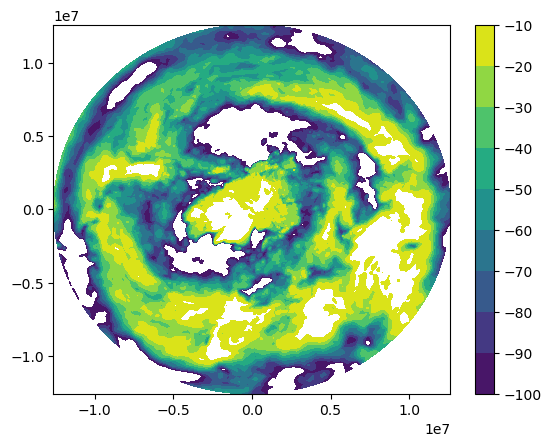

In [17]:
# Now, try plotting using the projected coordinates directly with standard matplotlib
# This essentially mimics what transform_first=True does internally
fig_debug, ax_debug = plt.subplots()
img_debug = ax_debug.contourf(x_proj, y_proj, x_cyclic, levels=levels)
fig_debug.colorbar(img_debug)


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Plotting with explicit projection took: 0.018 seconds


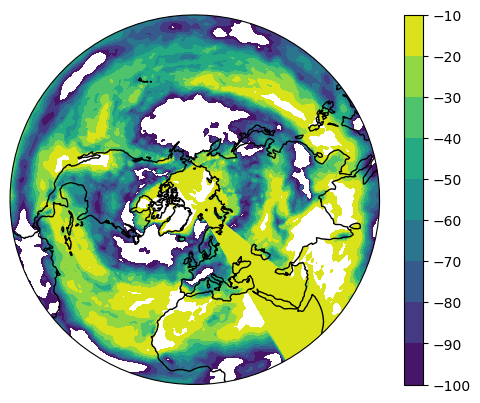

In [36]:
x_nh = x.sel(lat=slice(0,90))


# TEST ORIENTATION BY MODIFYING x_nh
x_nh = x_nh.where(~((x_nh.lon >= 30) & (x_nh.lon <= 50)), -10)

# --- Convert longitudes to -180 to 180 range ---
# lon_180 = (x_nh.lon + 180) % 360 - 180
# x_nh_adjusted = x_nh.assign_coords(lon=lon_180).sortby('lon')

x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x_nh.lon)

lons, lats = np.meshgrid(lon_cyclic, x_nh_adjusted.lat)

levels = np.arange(-100, 0, 10)

proj = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(subplot_kw={"projection":proj})

start_time = time.time()

# --- Explicitly project coordinates using the projection object ---
# This is what transform_first=True *should* be doing internally.
# But since it's not working, we do it manually.
x_proj, y_proj, _ = proj.transform_points(ccrs.PlateCarree(), lons, lats).T # .T to unpack, .T again to get x,y,z arrays

x_proj = x_proj.T
y_proj = y_proj.T

print(type(x_proj))
print(type(y_proj))

# Now plot using the projected coordinates directly on the axes
# NO 'transform=ccrs.PlateCarree()' here, as the data is already transformed
img1 = ax.contourf(x_proj, y_proj, x_cyclic, levels=levels)

ax.coastlines()
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

end_time = time.time()
print(f"Plotting with explicit projection took: {end_time - start_time:.3f} seconds")


In [30]:
type(proj)

cartopy.crs.NorthPolarStereo

In [33]:
isinstance(proj, ccrs.CRS)

True